In [23]:
import os
import random
import scipy.io
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from KANSRF import ColorKANSRF


In [24]:
number_of_primitives = 3
visible_range = True#Use False to select entire spectrum
include_shadows = True
no_of_epochs = 30
#Visible range of pavia dataset has 66 bands and full spectrum has 103 bands
no_of_bands = 66 if visible_range else 103
output_classes = 9 if include_shadows else 8

In [25]:
hsi = scipy.io.loadmat("PaviaU.mat")
image = hsi["paviaU"]

gt = scipy.io.loadmat("PaviaU_gt.mat")
index = gt["paviaU_gt"]
image  =image[:, :, :no_of_bands]

print(image.shape)
print(index.shape)

(610, 340, 66)
(610, 340)


In [26]:
#Normalizing the image
max_val = np.max(image)
normalized_image = image.astype(np.float32) / max_val

In [27]:

image_for_training = normalized_image[:,:,:no_of_bands]
print(image_for_training.shape)

(610, 340, 66)


In [28]:
x = []
for i in range(len(image_for_training)):
    for j in range(len(image_for_training[0])):
        if (index[i][j] == 0) or (index[i][j] == 9 and (not include_shadows)): #Ignoring all unclassified pixels
            continue
        x.append(image_for_training[i][j])

x = np.asarray(x,dtype=np.float32)
print(x.shape)

(42776, 66)


In [29]:
y = []

for i in range(len(image)):
    for j in range(len(image[0])):
        if index[i][j] == 0 or \
           (index[i][j] == 9 and (not include_shadows)):
            continue

        y.append(index[i][j]-1)

y = np.asarray(y , dtype=np.int64)
y.shape

(42776,)

In [30]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = ColorKANSRF(
    no_of_bands=no_of_bands,
    number_of_primitives=number_of_primitives,
    output_classes=output_classes,
    num_grids=12,
    nonnegative=False
).to(device)



Using device: cpu


In [31]:
print(model)

ColorKANSRF(
  (primitives): ModuleList(
    (0-2): 3 x KANSpectralPrimitive(
      (rbf): GaussianRBF()
    )
  )
  (classifier_dense): Linear(in_features=3, out_features=9, bias=True)
)


In [32]:
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

model = model.to(device)

summary(
    model,
    input_size=(1, no_of_bands))

optimizer = torch.optim.Adam(
    model.parameters(),)

criterion = nn.CrossEntropyLoss()

x_tensor = torch.tensor( x,dtype=torch.float32)

y_tensor = torch.tensor( y,dtype=torch.long)

batch_size = 32

dataset = TensorDataset(x_tensor,y_tensor)

train_loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

loss_history = []
accuracy_history = []

for epoch in range(no_of_epochs):

    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()

        output = model(batch_x)

        loss = criterion(output,batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)

        predictions = torch.argmax(output,dim=1)

        total_correct += ( predictions == batch_y).sum().item()

        total_samples += batch_y.size(0)

    epoch_loss = total_loss / total_samples

    epoch_accuracy = (total_correct / total_samples
    )

    loss_history.append(
        epoch_loss
    )

    accuracy_history.append(
        epoch_accuracy
    )

    print(
        f"Epoch [{epoch+1}/{no_of_epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.4f}"
    )

Using device: cpu
Epoch [1/30] | Loss: 1.8192 | Accuracy: 0.3646
Epoch [2/30] | Loss: 1.4075 | Accuracy: 0.4798
Epoch [3/30] | Loss: 1.2812 | Accuracy: 0.5294
Epoch [4/30] | Loss: 1.2160 | Accuracy: 0.5557
Epoch [5/30] | Loss: 1.1717 | Accuracy: 0.5682
Epoch [6/30] | Loss: 1.1382 | Accuracy: 0.5776
Epoch [7/30] | Loss: 1.1106 | Accuracy: 0.5904
Epoch [8/30] | Loss: 1.0857 | Accuracy: 0.6024
Epoch [9/30] | Loss: 1.0625 | Accuracy: 0.6155
Epoch [10/30] | Loss: 1.0396 | Accuracy: 0.6324
Epoch [11/30] | Loss: 1.0168 | Accuracy: 0.6481
Epoch [12/30] | Loss: 0.9944 | Accuracy: 0.6624
Epoch [13/30] | Loss: 0.9723 | Accuracy: 0.6780
Epoch [14/30] | Loss: 0.9524 | Accuracy: 0.6908
Epoch [15/30] | Loss: 0.9335 | Accuracy: 0.6993
Epoch [16/30] | Loss: 0.9167 | Accuracy: 0.7061
Epoch [17/30] | Loss: 0.9015 | Accuracy: 0.7136
Epoch [18/30] | Loss: 0.8885 | Accuracy: 0.7170
Epoch [19/30] | Loss: 0.8770 | Accuracy: 0.7220
Epoch [20/30] | Loss: 0.8664 | Accuracy: 0.7252
Epoch [21/30] | Loss: 0.8575 | 

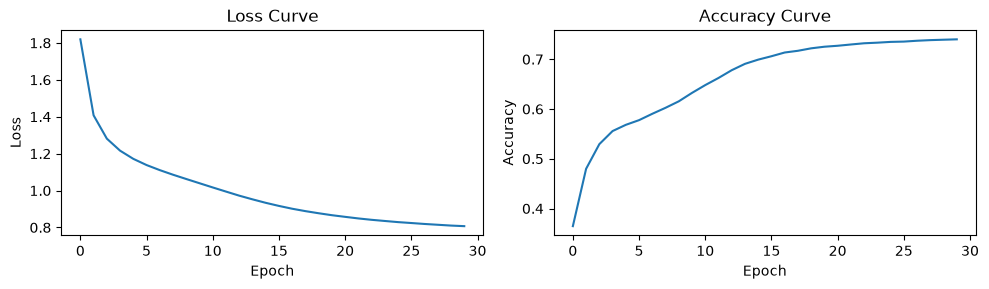

In [33]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(accuracy_history)
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

In [34]:
wavelength = np.linspace(430, 860, no_of_bands) #430 - 860 is range of paviaU dataset and 103 is number of bands
wavelength_int = wavelength.astype(int)
print(wavelength_int)

[430 436 443 449 456 463 469 476 482 489 496 502 509 516 522 529 535 542
 549 555 562 568 575 582 588 595 602 608 615 621 628 635 641 648 654 661
 668 674 681 688 694 701 707 714 721 727 734 740 747 754 760 767 774 780
 787 793 800 807 813 820 826 833 840 846 853 860]


Primitive 1 SRF shape: (66,)


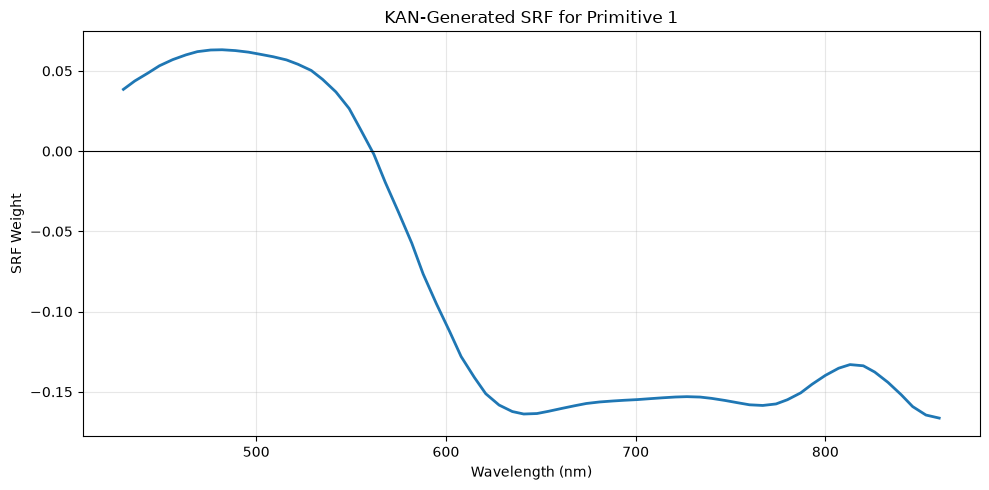

Primitive 2 SRF shape: (66,)


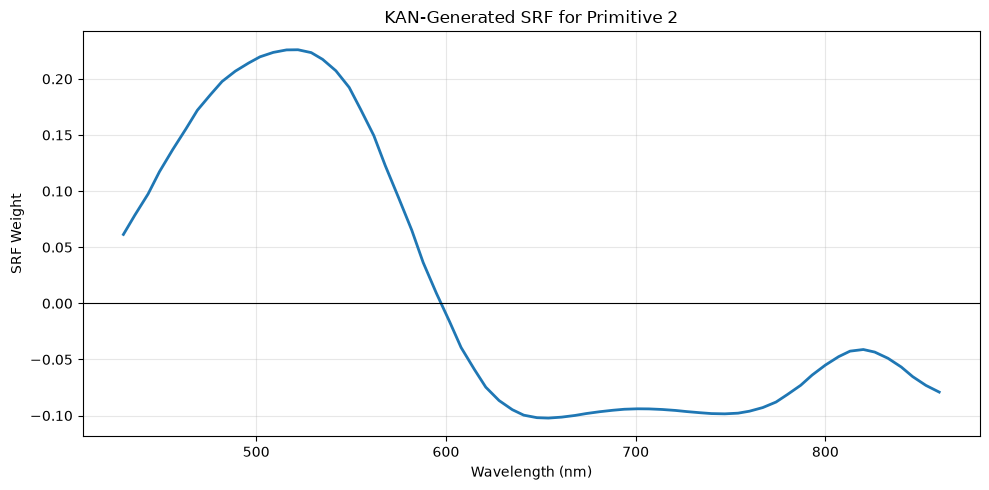

Primitive 3 SRF shape: (66,)


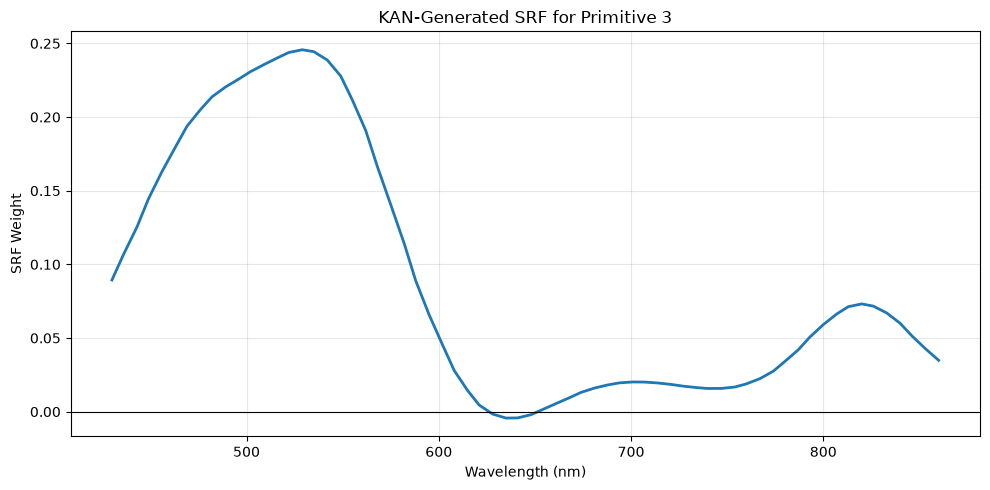

In [35]:
primitive_curves = []

model.eval()

for primitive_no in range(number_of_primitives):

    with torch.no_grad():

        curve = (
            model.primitives[primitive_no]
            .get_srf()
            .cpu()
            .numpy()
        )

    primitive_curves.append(curve)

    print(
        f"Primitive {primitive_no + 1} "
        f"SRF shape: {curve.shape}"
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        wavelength_int[:no_of_bands],
        curve,
        linewidth=2
    )

    plt.axhline(
        0,
        color="black",
        linewidth=0.8
    )

    plt.title(
        f"KAN-Generated SRF for "
        f"Primitive {primitive_no + 1}"
    )

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("SRF Weight")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [36]:
for i ,p in enumerate(primitive_curves):
    print(i+1, f"primitive_{i+1}" , p[0])



1 primitive_1 0.03848362
2 primitive_2 0.061376605
3 primitive_3 0.089383684


In [37]:
for i, (name, parameter) in enumerate(model.named_parameters()):
    if parameter.requires_grad:
        print(i, name, parameter.shape)

0 primitives.0.rbf_coefficients torch.Size([12])
1 primitives.0.base_coefficient torch.Size([1])
2 primitives.0.srf_offset torch.Size([1])
3 primitives.0.output_bias torch.Size([1])
4 primitives.1.rbf_coefficients torch.Size([12])
5 primitives.1.base_coefficient torch.Size([1])
6 primitives.1.srf_offset torch.Size([1])
7 primitives.1.output_bias torch.Size([1])
8 primitives.2.rbf_coefficients torch.Size([12])
9 primitives.2.base_coefficient torch.Size([1])
10 primitives.2.srf_offset torch.Size([1])
11 primitives.2.output_bias torch.Size([1])
12 classifier_dense.weight torch.Size([9, 3])
13 classifier_dense.bias torch.Size([9])


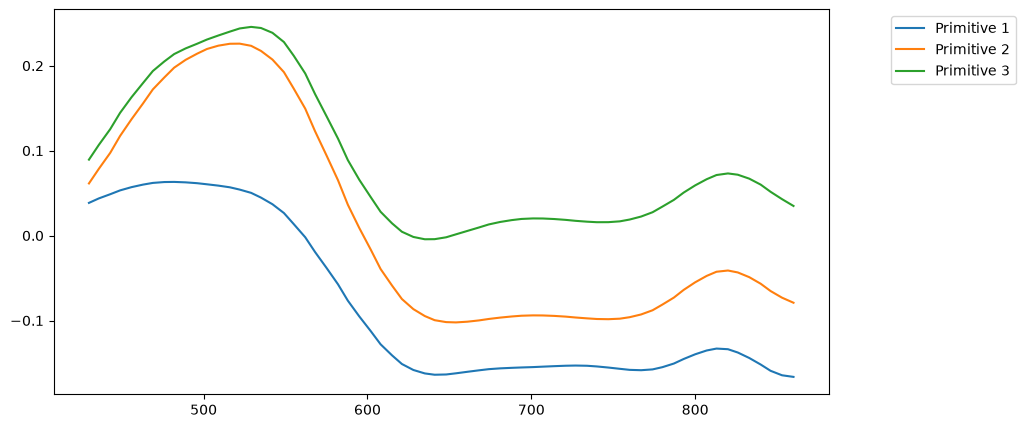

In [38]:

plt.figure(figsize=(10, 5))

for primitive_no in range(number_of_primitives):

    plt.plot(wavelength_int[:no_of_bands],primitive_curves[primitive_no],label=f"Primitive {primitive_no + 1}")
plt.legend(bbox_to_anchor=(1.25, 1))
plt.show()




In [39]:
model_name = (
    f'{no_of_bands}bands_'f'{number_of_primitives}primitives_' f'{"with_shadow" if include_shadows else "without_shadow"}_' f'fastkan_random_init')
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [40]:
print(model_name)

66bands_3primitives_with_shadow_fastkan_random_init


In [41]:
torch.save(model.state_dict(), f"{model_name}.pth")

In [42]:
model = ColorKANSRF(
    no_of_bands,
    number_of_primitives,
    output_classes
)

model.load_state_dict(torch.load(f"{model_name}.pth"))
model.eval()

ColorKANSRF(
  (primitives): ModuleList(
    (0-2): 3 x KANSpectralPrimitive(
      (rbf): GaussianRBF()
    )
  )
  (classifier_dense): Linear(in_features=3, out_features=9, bias=True)
)

In [43]:
def predict_image():
    x_pred = image_for_training.reshape(-1, no_of_bands)

    print("Prediction Input Shape:", x_pred.shape)
    print("Predicting...")

    x_pred = torch.tensor( x_pred,dtype=torch.float32, device=device)

    model.eval()

    with torch.no_grad():

        primitive_outputs = [primtive(x_pred) for primtive in model.primitives]
        prediction = torch.cat(primitive_outputs,dim=1)

    predicted_image = prediction.cpu().numpy().reshape(
        image.shape[0],
        image.shape[1],
        number_of_primitives
    )

    return predicted_image
def normalize_images(predicted_image, channels):

    max_val = np.max(predicted_image)

    if max_val == 0:
        global_max_image = predicted_image.copy()
    else:
        global_max_image = predicted_image / max_val

    signed_channelwise_image = np.zeros_like(predicted_image , dtype=np.float32)

    for i in range(predicted_image.shape[-1]):

        channel = predicted_image[:, :, i]

        channel_max = np.max(np.abs(channel))

        if channel_max!= 0:
            signed_channelwise_image[:, :, i] = (
                channel / channel_max
            )
        else:
            signed_channelwise_image[:, :, i] = channel
    clipped_image = np.clip(
        predicted_image,0,1)
    channel_minmax_image = np.zeros_like(predicted_image , dtype=np.float32)
    for i in range(predicted_image.shape[-1]):
        channel = predicted_image[: , : , i]
        channel_min = np.min(channel)
        channel_max = np.max(channel)
        channel_minmax_image[: ,: ,i] = (channel -channel_min)/(channel_max -channel_min + 1e-8)
    c1 , c2 , c3 = [channel -1 for channel in channels]

    rgb_global_max = np.dstack((
        global_max_image[:, :, c1],
        global_max_image[:, :, c2],
        global_max_image[:, :, c3]
    ))

    rgb_signed_channelwise = np.dstack((
        signed_channelwise_image[:, :, c1],
        signed_channelwise_image[:, :, c2],
        signed_channelwise_image[:, :, c3]
    ))

    rgb_clipped = np.dstack((
        clipped_image[:, :, c1],
        clipped_image[:, :, c2],
        clipped_image[:, :, c3]
    ))
   
    return [
        rgb_global_max ,
        rgb_signed_channelwise,
        rgb_clipped
    ]

Prediction Input Shape: (207400, 66)
Predicting...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1581657..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


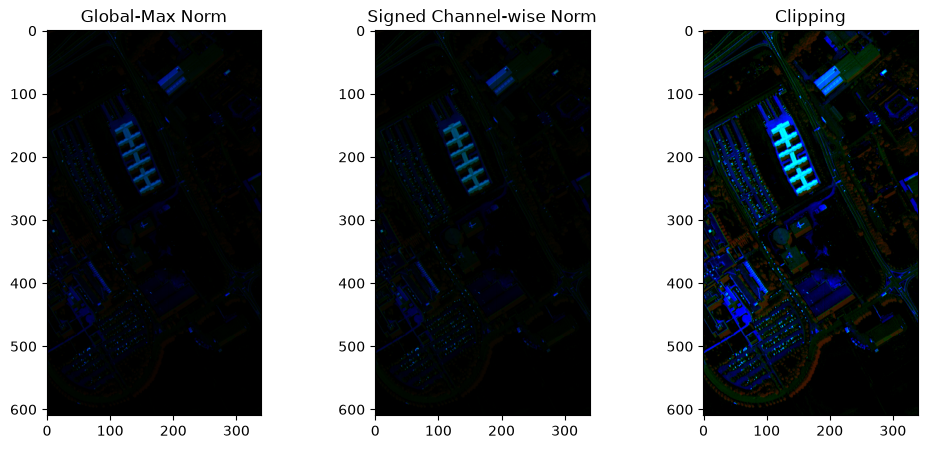

In [44]:
channels = [1, 2, 3]

predicted_image = predict_image()

normalized_images = normalize_images(
    predicted_image,
    channels
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(normalized_images[0])
plt.title("Global-Max Norm")

plt.subplot(1, 3, 2)
plt.imshow(normalized_images[1])
plt.title("Signed Channel-wise Norm")

plt.subplot(1, 3, 3)
plt.imshow(normalized_images[2])
plt.title("Clipping")

plt.show()